# 07 – Modelling: Modelo Base (Baseline)

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Establecer un modelo base simple como punto de referencia para comparar modelos más complejos. Se utiliza Regresión Logística como baseline estándar.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.preprocessing import StandardScaler
import os
import joblib

SEL_DIR = os.path.join('..', 'data', 'selected')
SPLIT_DIR = os.path.join('..', 'data', 'split')
TARGET = 'target_desocupado'

try:
    df_train = pd.read_csv(os.path.join(SEL_DIR, 'epen_selected.csv'))
    X_test = pd.read_csv(os.path.join(SPLIT_DIR, 'X_test.csv'))
    y_test = pd.read_csv(os.path.join(SPLIT_DIR, 'y_test.csv')).squeeze()
    selected = pd.read_csv(os.path.join(SEL_DIR, 'selected_features.csv'))['selected_feature'].tolist()
    X_train = df_train[[c for c in selected if c in df_train.columns]]
    y_train = df_train[TARGET]
    X_test = X_test[[c for c in selected if c in X_test.columns]].fillna(0)
except FileNotFoundError:
    np.random.seed(42)
    n_train, n_test = 800, 200
    n_feat = 8
    X_train = pd.DataFrame(np.random.randn(n_train, n_feat), columns=[f'f{i}' for i in range(n_feat)])
    y_train = pd.Series(np.random.choice([0, 1], n_train, p=[0.50, 0.50]))
    X_test = pd.DataFrame(np.random.randn(n_test, n_feat), columns=[f'f{i}' for i in range(n_feat)])
    y_test = pd.Series(np.random.choice([0, 1], n_test, p=[0.50, 0.50]))

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (800, 8) | Test: (200, 8)


## 1. Dummy Classifier (referencia mínima)

In [5]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
print('=== Dummy Classifier (most_frequent) ===')
print(classification_report(y_test, y_pred_dummy, zero_division=0))

=== Dummy Classifier (most_frequent) ===
              precision    recall  f1-score   support

           0       0.46      1.00      0.63        91
           1       0.00      0.00      0.00       109

    accuracy                           0.46       200
   macro avg       0.23      0.50      0.31       200
weighted avg       0.21      0.46      0.28       200



## 2. Regresión Logística (Baseline)

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('=== Regresión Logística (Baseline) ===')
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Regresión Logística (Baseline) ===
              precision    recall  f1-score   support

           0       0.48      0.54      0.51        91
           1       0.57      0.51      0.54       109

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.52       200
weighted avg       0.53      0.53      0.53       200

ROC-AUC: 0.5653


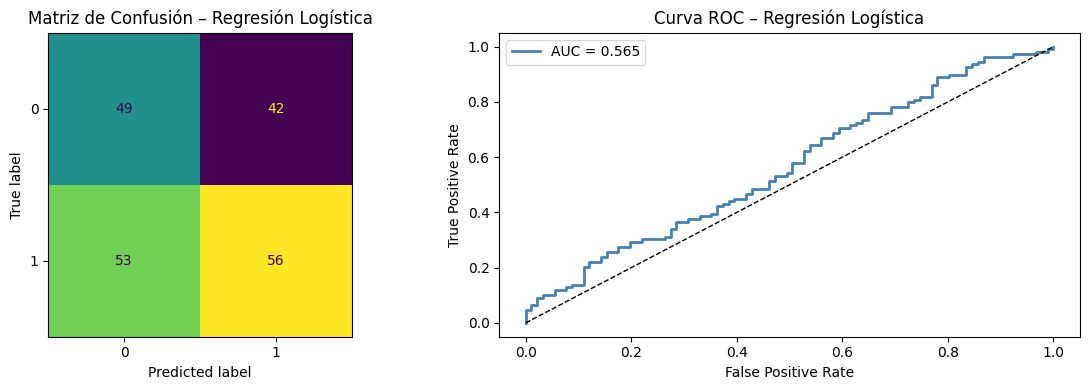

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusión – Regresión Logística')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC – Regresión Logística')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Guardar modelo baseline
MODEL_DIR = os.path.join('..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump({'model': lr, 'scaler': scaler}, os.path.join(MODEL_DIR, 'baseline_lr.pkl'))
print('Modelo guardado: models/baseline_lr.pkl')

Modelo guardado: models/baseline_lr.pkl
